In [123]:
import pickle as pkl
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [104]:
upos_to_utag = {
    "ADJ": "ADJ",
    "ADP": "ADP",
    "ADV": "ADV",
    "AUX": "VERB",
    "CCONJ": "CONJ",
    "DET": "DET",
    "INTJ": "PRT",
    "NOUN": "NOUN",
    "NUM": "NUM",
    "PART": "PRT",
    "PRON": "PRON",
    "PROPN": "NOUN",
    "PUNCT": ".",
    "SCONJ": "CONJ",
    "SYM": ".",
    "VERB": "VERB",
    "X": "X",
}

In [109]:
device = "xpu" if torch.xpu.is_available() else "cpu"

In [110]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
name = "TweebankNLP/bertweet-tb2_ewt-pos-tagging"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForTokenClassification.from_pretrained(name)
generator = pipeline(task="token-classification", model=name, tokenizer=name, device=device)

Device set to use xpu


In [8]:
with open("../data/test_data.pkl", "rb") as f:
	test_data = pkl.load(f)

In [120]:
preds = []
actuals = []
skipped_sents = []

In [121]:
for test in tqdm(test_data):
	test_sentence = " ".join([word for word, _ in test])
	outputs = generator(test_sentence)
	pos_tags = [output["entity"] for output in outputs if not output["word"].endswith("@@")]
	pos_tags = [upos_to_utag[tag] for tag in pos_tags]
	try:
		assert len(pos_tags) == len(test), f"Length mismatch: {len(pos_tags)} vs {len(test)}"
		preds += pos_tags
		actuals += [tag for _, tag in test]
	except Exception as e:
		print(f"Error processing sentence '{test_sentence}': {e}")
		skipped_sents.append(test_sentence)
		continue

  1%|          | 35/5734 [00:01<02:29, 38.21it/s]

Error processing sentence 'i saw him myself and it was done after consultation with cromwell .': Length mismatch: 14 vs 13


  1%|▏         | 74/5734 [00:01<01:55, 49.15it/s]

Error processing sentence 'the lack of scientific unanimity on the effects of radiation is due in part to insufficient data covering large population groups , from which agreed-on generalizations could be drawn .': Length mismatch: 31 vs 30


  7%|▋         | 426/5734 [00:08<01:43, 51.39it/s]

...

 98%|█████████▊| 5614/5734 [02:48<00:02, 44.35it/s]

Error processing sentence 'the son of a wealthy evanston executive was fined $100 yesterday and forbidden to drive for 60 days for leading an evanston policeman on a high speed chase over icy evanston and wilmette streets jan. 20 .': Length mismatch: 38 vs 37


 98%|█████████▊| 5644/5734 [02:49<00:02, 44.09it/s]

Error processing sentence 'amid a shortage of profitable work , the memory of albert johnson's $20,000 stood out in lonely grandeur -- the money had quickly melted away .': Length mismatch: 27 vs 26


100%|██████████| 5734/5734 [02:51<00:00, 33.42it/s]


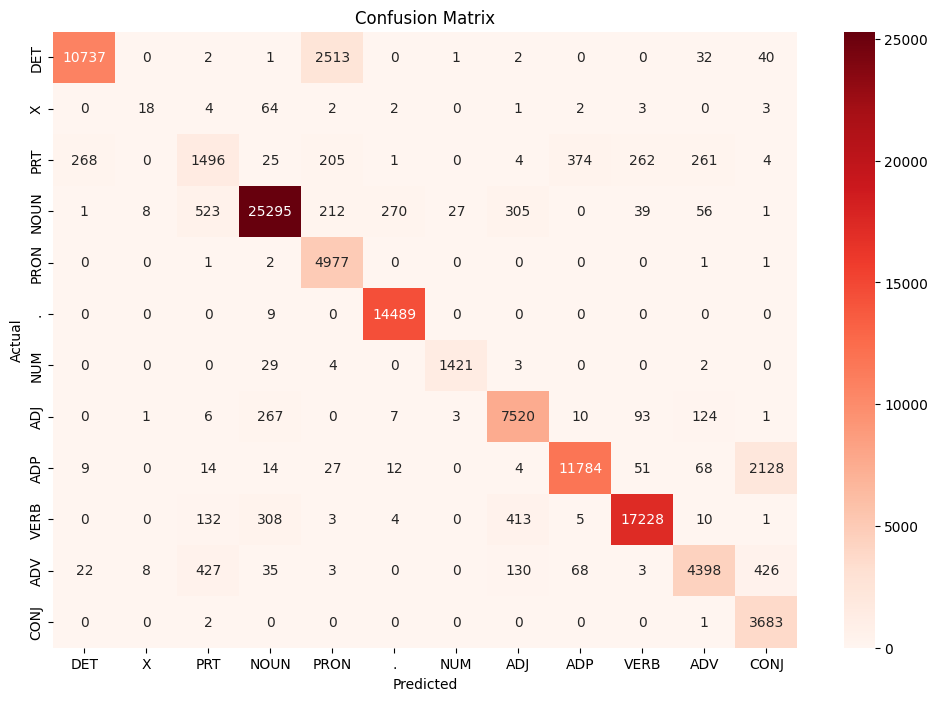

In [125]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(set(upos_to_utag.values())))
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(set(upos_to_utag.values())),
    yticklabels=list(set(upos_to_utag.values())),
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

In [126]:
print(classification_report(
    actuals, preds, labels=list(set(upos_to_utag.values())), digits=4
))

              precision    recall  f1-score   support

         DET     0.9728    0.8056    0.8813     13328
           X     0.5143    0.1818    0.2687        99
         PRT     0.5738    0.5159    0.5433      2900
        NOUN     0.9711    0.9461    0.9584     26737
        PRON     0.6264    0.9990    0.7700      4982
           .     0.9800    0.9994    0.9896     14498
         NUM     0.9787    0.9740    0.9763      1459
         ADJ     0.8972    0.9363    0.9163      8032
         ADP     0.9625    0.8351    0.8943     14111
        VERB     0.9745    0.9516    0.9629     18104
         ADV     0.8879    0.7967    0.8399      5520
        CONJ     0.5857    0.9992    0.7385      3686

    accuracy                         0.9082    113456
   macro avg     0.8271    0.8284    0.8116    113456
weighted avg     0.9245    0.9082    0.9109    113456

